In [1]:
import torch
import cv2
import numpy as np
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

/opt/dlami/nvme/mitunet_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHTS_PATH = "/opt/dlami/nvme/mitunet_weights/mitunet.pth"

In [3]:
aux_segformer = smp.Segformer(encoder_name="mit_b4", encoder_weights=None)
model = smp.Unet(
    encoder_name="mit_b4",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"
)
# Transplant the encoder
model.encoder = aux_segformer.encoder

# 3. Load trained weights
state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

/tmp/ipykernel_27431/2368169390.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)


Unet(
  (encoder): MixVisionTransformerEncoder(
    (patch_embed1): OverlapPatchEmbed(
      (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed2): OverlapPatchEmbed(
      (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed3): OverlapPatchEmbed(
      (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed4): OverlapPatchEmbed(
      (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (block1): Sequential(
      (0): Block(
        (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (q): Linear(in_features=64

In [4]:
transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [5]:

def predict(img_path, mask_path=None, show=True):

    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    augmented = transform(image=image_rgb)
    input_tensor = augmented['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        mask = (probs > 0.5).float()

    result_mask = mask.squeeze().cpu().numpy()

    # ---------------------------------
    # Load GT mask if provided
    # ---------------------------------
    gt_mask = None

    if mask_path is not None:
        gt_mask = cv2.imread(mask_path, 0)

        # wall only
        gt_mask = (gt_mask == 1).astype(np.uint8)

    # ---------------------------------
    # Plot
    # ---------------------------------
    if show:

        cols = 3 if gt_mask is not None else 2

        plt.figure(figsize=(18, 6))

        # Original image
        plt.subplot(1, cols, 1)
        plt.title("Original Image")
        plt.imshow(image_rgb)
        plt.axis('off')

        # Prediction
        plt.subplot(1, cols, 2)
        plt.title("Predicted Mask")
        plt.imshow(result_mask, cmap='gray')
        plt.axis('off')

        # GT mask
        if gt_mask is not None:
            plt.subplot(1, cols, 3)
            plt.title("GT Wall Mask")
            plt.imshow(gt_mask, cmap='gray')
            plt.axis('off')

        plt.show()

    return result_mask

  0%|          | 0/2 [00:00<?, ?it/s]

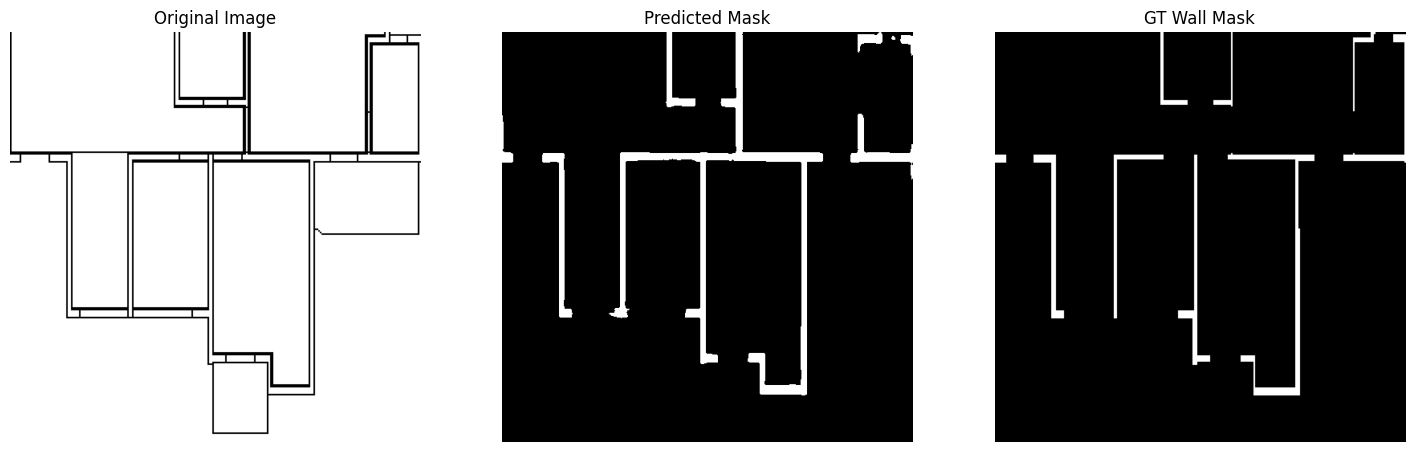

 50%|█████     | 1/2 [00:00<00:00,  1.93it/s]

<class 'numpy.ndarray'>


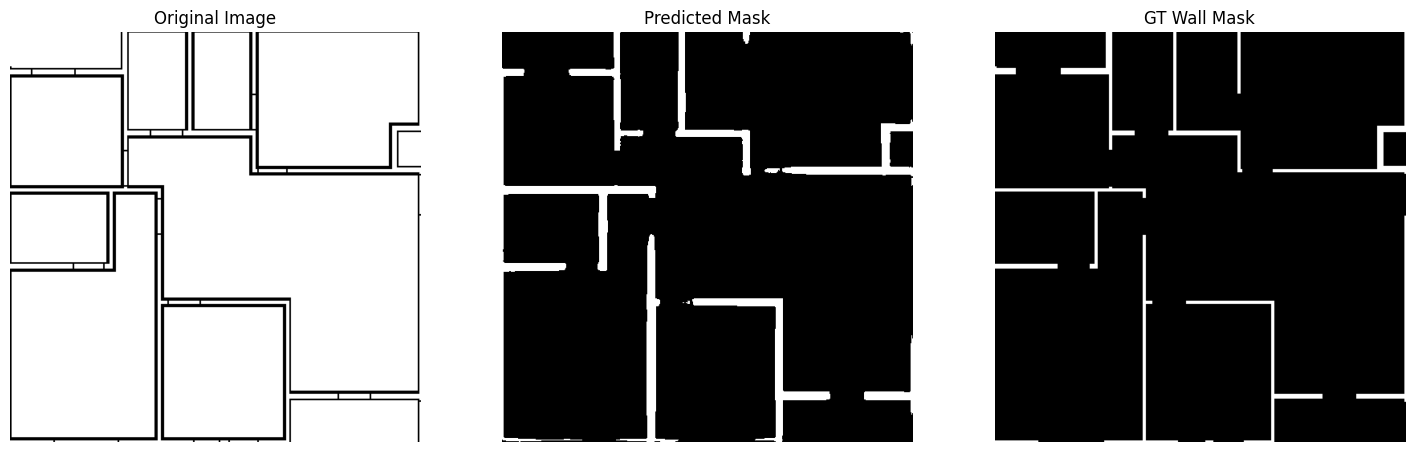

100%|██████████| 2/2 [00:00<00:00,  2.42it/s]

<class 'numpy.ndarray'>
mIoU : 0.4949354401976278
mAP  : 0.4731386698060951


In [6]:
import numpy as np
from sklearn.metrics import jaccard_score, average_precision_score
from tqdm import tqdm

ious = []
aps = []

dataset_path = "/opt/dlami/nvme/mitunet_dataset_1/images"
mask_path    = "/opt/dlami/nvme/mitunet_dataset_1/masks"

for i in tqdm(range(2)):

    # -----------------------------
    # Image path
    # -----------------------------
    img_path = f"{dataset_path}/{i:05d}.png"

    # -----------------------------
    # Ground truth mask
    # -----------------------------
    gt_mask = cv2.imread(
        f"{mask_path}/{i:05d}.png",
        0
    )

    # Wall class only
    gt_wall = (gt_mask == 1).astype(np.uint8)

    # -----------------------------
    # Prediction
    # -----------------------------
    pred_mask = predict(img_path, mask_path=f"{mask_path}/{i:05d}.png", show=True)

    print(type(pred_mask))

    # Binary prediction
    pred_wall = (pred_mask > 0).astype(np.uint8)
    # resize prediction to GT mask size
    pred_wall = cv2.resize(
        pred_wall.astype(np.uint8),
        (gt_wall.shape[1], gt_wall.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # -----------------------------
    # Flatten
    # -----------------------------
    gt   = gt_wall.flatten()
    pred = pred_wall.flatten()

    # -----------------------------
    # IoU
    # -----------------------------
    iou = jaccard_score(
        gt,
        pred,
        average="binary"
    )

    ious.append(iou)

    # -----------------------------
    # AP
    # -----------------------------
    ap = average_precision_score(
        gt,
        pred
    )

    aps.append(ap)

# -----------------------------
# Final metrics
# -----------------------------
print("mIoU :", np.mean(ious))
print("mAP  :", np.mean(aps))

In [7]:
import numpy as np
from skimage.morphology import skeletonize

def extract_line_points(mask):
    """
    mask:
        binary numpy array
        0 = background
        1 = wall/line

    Returns:
        endpoints : [(x, y), ...]
        junctions : [(x, y), ...]
    """

    # skeletonize
    skel = skeletonize(mask).astype(np.uint8)

    endpoints = []
    junctions = []

    h, w = skel.shape

    for y in range(1, h - 1):
        for x in range(1, w - 1):

            if skel[y, x] == 0:
                continue

            # count neighbors
            neighbors = np.sum(
                skel[y-1:y+2, x-1:x+2]
            ) - skel[y, x]

            if neighbors == 1:
                endpoints.append((x, y))

            elif neighbors >= 3:
                junctions.append((x, y))

    return endpoints, junctions

In [8]:
idx = np.random.randint(0, 100)  # Randomly select an index for testing
img_path = f"{dataset_path}/{idx:05d}.png"
pred_wall = predict(img_path, show=False)

print(pred_wall, np.max(pred_wall), np.min(pred_wall))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 1. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] 1.0 0.0


In [9]:
endpoints, junctions = extract_line_points(pred_wall)

print("Endpoints:", endpoints)
print("Junctions:", junctions)

Endpoints: [(509, 1), (337, 2), (113, 3), (197, 3), (264, 3), (416, 3), (461, 3), (417, 20), (113, 27), (460, 48), (231, 117), (300, 117), (337, 151), (196, 160), (339, 189), (461, 190), (382, 219), (152, 220), (192, 220), (339, 220), (510, 239), (510, 288), (338, 291), (377, 291), (510, 317), (358, 339), (55, 388), (209, 423), (57, 431), (510, 433), (483, 439), (337, 450), (337, 491), (281, 504), (108, 505), (165, 505), (357, 505), (409, 505), (53, 506), (389, 506)]
Junctions: [(337, 115), (336, 116), (337, 116), (337, 117), (196, 218), (264, 218), (460, 218), (507, 218), (4, 219), (196, 219), (197, 219), (263, 219), (264, 219), (265, 219), (337, 219), (415, 219), (416, 219), (417, 219), (460, 219), (461, 219), (506, 219), (507, 219), (336, 220), (337, 220), (338, 220), (416, 220), (416, 291), (508, 291), (415, 292), (416, 292), (417, 292), (507, 292), (508, 292), (508, 293), (338, 338), (338, 339), (339, 339), (338, 340), (55, 369), (56, 369), (57, 369), (56, 370), (197, 423), (197, 

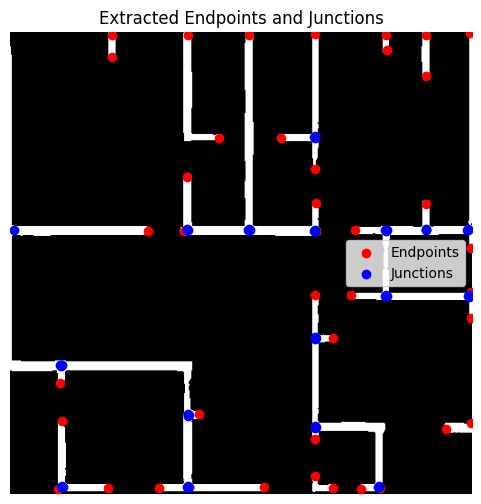

In [10]:
# plot the points on the mask image
plt.figure(figsize=(6, 6))
plt.imshow(pred_wall, cmap='gray')
if endpoints:
    ex, ey = zip(*endpoints)
    plt.scatter(ex, ey, c='red', label='Endpoints')
if junctions:
    jx, jy = zip(*junctions)
    plt.scatter(jx, jy, c='blue', label='Junctions')
plt.legend()
plt.title("Extracted Endpoints and Junctions")
plt.axis('off')
plt.show()

In [11]:
import numpy as np
from skimage.morphology import skeletonize
from collections import deque

def build_graph_from_mask(mask):
    """
    mask:
        binary image (0/1)

    Returns:
        graph = {
            "nodes": {node_id: (x, y)},
            "edges": [(node_a, node_b, path_pixels)]
        }
    """

    # after skeletonization
    skel = skeletonize(mask).astype(np.uint8)


    h, w = skel.shape
    # -------------------------------------------------
    # STEP 1: detect nodes
    # -------------------------------------------------
    nodes = {}
    node_pixels = set()

    node_id = 0

    directions = [
        (-1, 0), (1, 0),
        (0, -1), (0, 1)
    ]

    for y in range(1, h - 1):
        for x in range(1, w - 1):

            if skel[y, x] == 0:
                continue

            neighbors_coords = []

            for dx, dy in directions:

                nx, ny = x + dx, y + dy

                if skel[ny, nx] == 1:
                    neighbors_coords.append((dx, dy))

            neighbor_count = len(neighbors_coords)

            is_endpoint = neighbor_count == 1
            is_junction = neighbor_count >= 3

            is_corner = False

            # exact L-corner
            if neighbor_count == 2:

                p1, p2 = neighbors_coords

                # not opposite directions
                if p1[0] != -p2[0] or p1[1] != -p2[1]:
                    is_corner = True

            if is_endpoint or is_junction or is_corner:
                nodes[node_id] = (x, y)
                node_pixels.add((x, y))
                node_id += 1

    # -------------------------------------------------
    # STEP 2: graph traversal
    # -------------------------------------------------
    visited = set()
    edges = []

    directions = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1)
    ]

    def get_neighbors(px, py):
        result = []

        for dx, dy in directions:
            nx, ny = px + dx, py + dy

            if (
                0 <= nx < w and
                0 <= ny < h and
                skel[ny, nx] == 1
            ):
                result.append((nx, ny))

        return result

    # node lookup
    pixel_to_node = {
        coord: nid for nid, coord in nodes.items()
    }

    # -------------------------------------------------
    # traverse from every node
    # -------------------------------------------------
    for start_id, (sx, sy) in nodes.items():

        for neighbor in get_neighbors(sx, sy):

            edge_key = tuple(sorted([(sx, sy), neighbor]))

            if edge_key in visited:
                continue

            path = [(sx, sy)]

            prev = (sx, sy)
            curr = neighbor

            while True:

                path.append(curr)

                visited.add(
                    tuple(sorted([prev, curr]))
                )

                # reached another node
                if curr in node_pixels and curr != (sx, sy):

                    end_id = pixel_to_node[curr]

                    edges.append(
                        (start_id, end_id, path)
                    )

                    break

                nbrs = get_neighbors(*curr)

                # remove previous pixel
                nbrs = [p for p in nbrs if p != prev]

                if len(nbrs) == 0:
                    break

                prev = curr
                curr = nbrs[0]

    graph = {
        "nodes": nodes,
        "edges": edges
    }

    return graph

In [12]:
graph = build_graph_from_mask(pred_wall)
print("Nodes:")
for nid, (x, y) in graph["nodes"].items():
    print(f"  {nid}: ({x}, {y})")
print("Edges:")
for node_a, node_b, path in graph["edges"]:
    print(f"  {node_a} <-> {node_b}, path length: {len(path)}")

Nodes:
  0: (509, 1)
  1: (337, 2)
  2: (509, 2)
  3: (264, 3)
  4: (337, 3)
  5: (416, 3)
  6: (510, 3)
  7: (112, 4)
  8: (196, 4)
  9: (338, 4)
  10: (460, 4)
  11: (416, 19)
  12: (112, 26)
  13: (460, 48)
  14: (338, 96)
  15: (337, 97)
  16: (196, 115)
  17: (197, 116)
  18: (229, 116)
  19: (302, 116)
  20: (337, 116)
  21: (230, 117)
  22: (231, 117)
  23: (300, 117)
  24: (301, 117)
  25: (337, 118)
  26: (338, 119)
  27: (338, 124)
  28: (337, 125)
  29: (337, 151)
  30: (196, 160)
  31: (338, 190)
  32: (460, 191)
  33: (338, 202)
  34: (337, 203)
  35: (510, 209)
  36: (337, 210)
  37: (509, 210)
  38: (338, 211)
  39: (1, 215)
  40: (1, 216)
  41: (509, 216)
  42: (338, 217)
  43: (337, 218)
  44: (507, 218)
  45: (4, 219)
  46: (30, 219)
  47: (40, 219)
  48: (150, 219)
  49: (196, 219)
  50: (264, 219)
  51: (298, 219)
  52: (382, 219)
  53: (416, 219)
  54: (441, 219)
  55: (460, 219)
  56: (461, 219)
  57: (471, 219)
  58: (507, 219)
  59: (31, 220)
  60: (39, 220)
  6

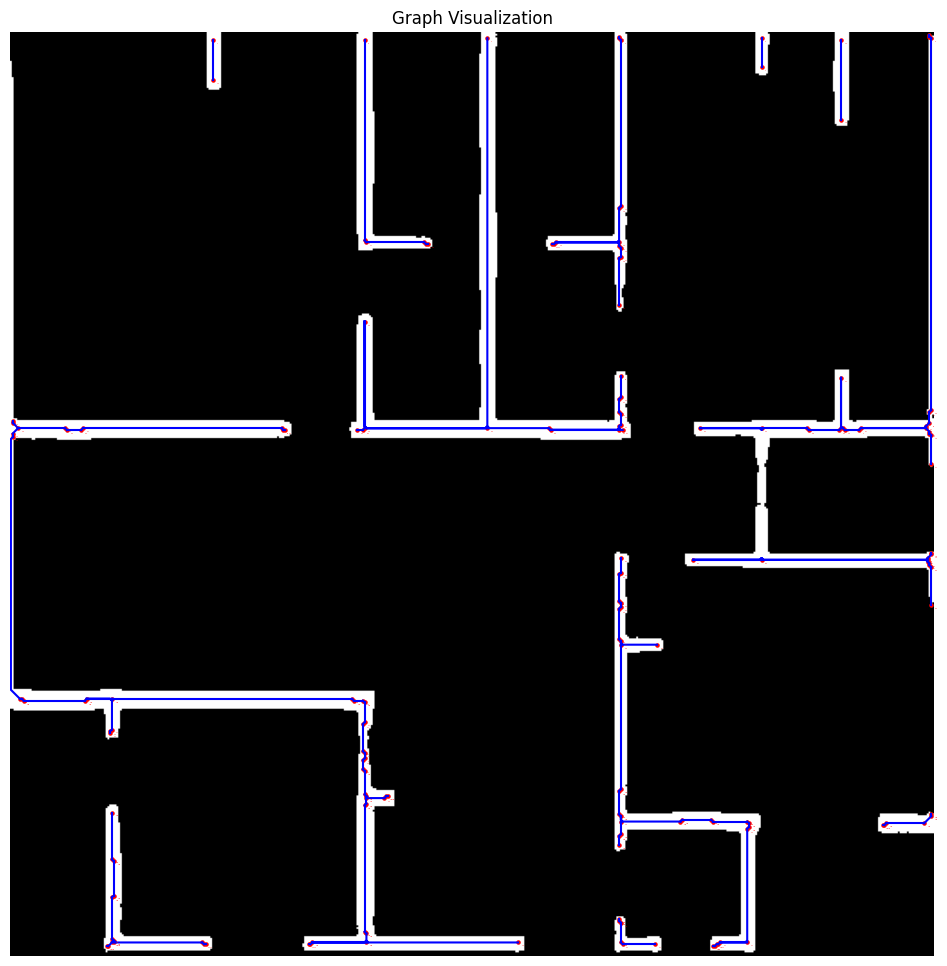

In [13]:
# plot this graph now
plt.figure(figsize=(12, 12))
plt.imshow(pred_wall, cmap='gray')
for nid, (x, y) in graph["nodes"].items():
    plt.scatter(x, y, c='red', s=5)
    plt.text(x+2, y+2, str(nid), color='red', fontsize=0)
for node_a, node_b, path in graph["edges"]:
    px, py = zip(*path)
    plt.plot(px, py, c='blue')
plt.title("Graph Visualization")
plt.axis('off')
plt.show()

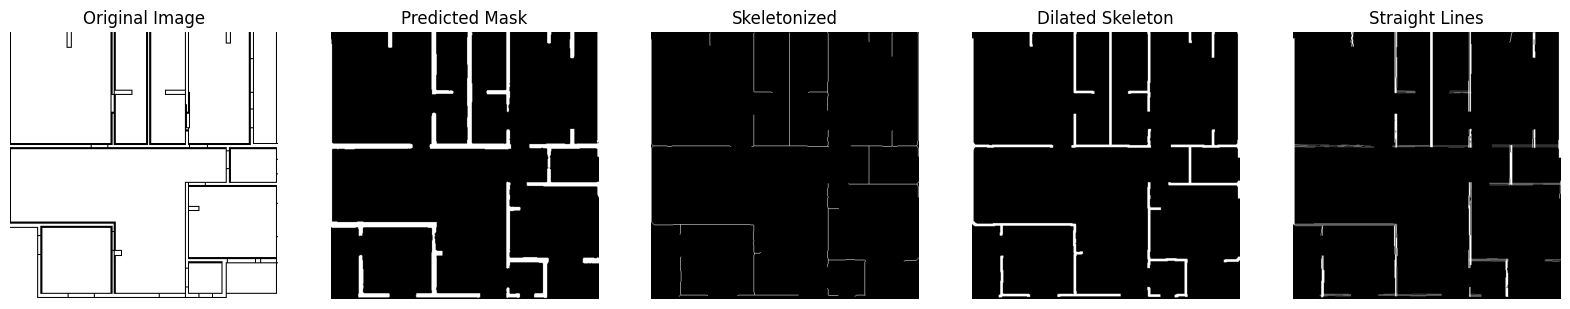

In [15]:
# apply skelotonization to the predicted mask
skel = skeletonize(pred_wall > 0).astype(np.uint8)
# apply dilation
dilated = cv2.dilate(
    skel,
    kernel=cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    iterations=1
)

# apply hough transform to extract straight lines
lines = cv2.HoughLinesP(
    dilated,
    rho=1,
    theta=np.pi/180,
    threshold=20,
    minLineLength=10,
    maxLineGap=15
)

# extract horizontal and vertical lines separately
horizontal_lines = []
vertical_lines = []

for line in lines:
    x1, y1, x2, y2 = line[0]

    if abs(y2 - y1) < 5:  # horizontal
        horizontal_lines.append(line)

    elif abs(x2 - x1) < 5:  # vertical
        vertical_lines.append(line)

straight_img = np.zeros_like(pred_wall)
# if lines is not None:
#     for line in lines:
#         x1, y1, x2, y2 = line[0]
#         cv2.line(
#             straight_img,
#             (x1, y1),
#             (x2, y2),
#             255,
#             1
#         )

for line in horizontal_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(
        straight_img,
        (x1, y1),
        (x2, y2),
        100,
        1
    )
for line in vertical_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(
        straight_img,
        (x1, y1),
        (x2, y2),
        255,
        1
    )

# plot
plt.figure(figsize=(20, 12))
plt.subplot(1, 5, 1)
plt.title("Original Image")
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.title("Predicted Mask")
plt.imshow(pred_wall, cmap='gray')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.title("Skeletonized")
plt.imshow(skel, cmap='gray')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.title("Dilated Skeleton")
plt.imshow(dilated, cmap='gray')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.title("Straight Lines")
plt.imshow(straight_img, cmap='gray')
plt.axis('off')
plt.show()

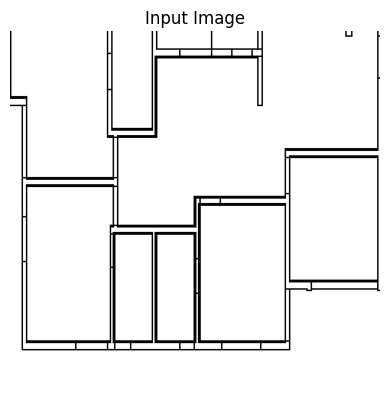

Total components found (excl. background): 7
  [KEEP] comp 1: area=  32644, bbox=(6,4,194,203)
  [KEEP] comp 2: area=  67829, bbox=(153,4,363,270)
  [KEEP] comp 3: area=  20620, bbox=(391,180,122,171)
  [KEEP] comp 4: area=  26284, bbox=(4,220,143,214)
  [KEEP] comp 5: area=  69438, bbox=(4,244,512,272)
  [KEEP] comp 6: area=   7837, bbox=(148,284,53,150)
  [KEEP] comp 7: area=   7710, bbox=(208,285,52,150)
Detected 7 rooms
  Room  1: bbox=(6, 4, 194, 203), centroid=(100, 94), area=32644
  Room  2: bbox=(153, 4, 363, 270), centroid=(329, 124), area=67829
  Room  3: bbox=(391, 180, 122, 171), centroid=(451, 264), area=20620
  Room  4: bbox=(4, 220, 143, 214), centroid=(81, 323), area=26284
  Room  5: bbox=(4, 244, 512, 272), centroid=(310, 422), area=69438
  Room  6: bbox=(148, 284, 53, 150), centroid=(173, 357), area=7837
  Room  7: bbox=(208, 285, 52, 150), centroid=(233, 359), area=7710


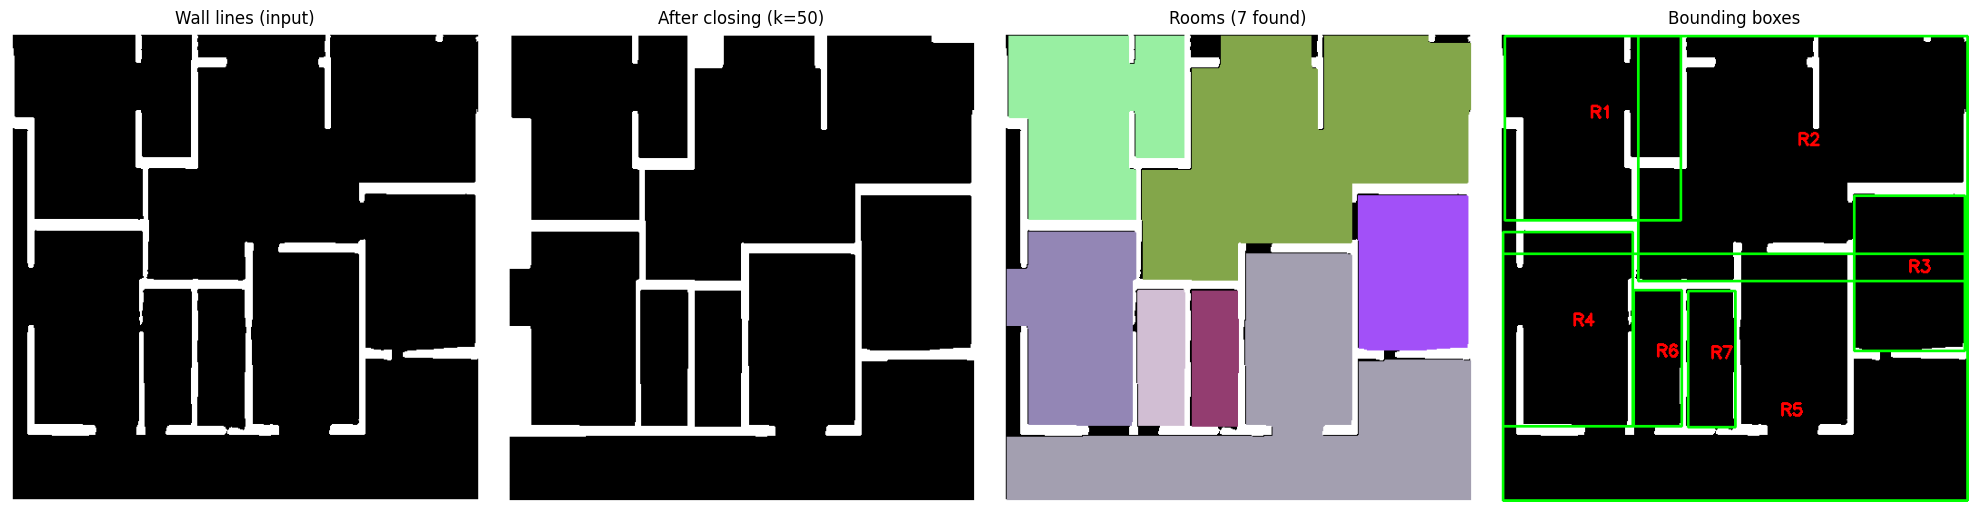

[{'id': 1,
  'label': 1,
  'bbox': (6, 4, 194, 203),
  'polygon': [[6, 4],
   [28, 206],
   [146, 206],
   [138, 88],
   [147, 138],
   [199, 138],
   [199, 4],
   [146, 4],
   [144, 35],
   [138, 4]],
  'centroid': (100, 94),
  'area': 32644,
  'contour': array([[[  6,   4]],
  
         [[ 28, 206]],
  
         [[146, 206]],
  
         [[138,  88]],
  
         [[147, 138]],
  
         [[199, 138]],
  
         [[199,   4]],
  
         [[146,   4]],
  
         [[144,  35]],
  
         [[138,   4]]], dtype=int32)},
 {'id': 2,
  'label': 2,
  'bbox': (153, 4, 363, 270),
  'polygon': [[154, 272],
   [383, 232],
   [385, 166],
   [511, 166],
   [515, 12],
   [354, 4],
   [348, 108],
   [339, 4],
   [240, 4],
   [208, 150],
   [153, 152]],
  'centroid': (329, 124),
  'area': 67829,
  'contour': array([[[154, 272]],
  
         [[383, 232]],
  
         [[385, 166]],
  
         [[511, 166]],
  
         [[515,  12]],
  
         [[354,   4]],
  
         [[348, 108]],
  
         [[

In [27]:
def find_room_boundaries(img_path, pred_wall):
    # Make a clean binary wall image from your straight_img
    wall_img = (pred_wall > 0).astype(np.uint8) * 255

    # Seal the image border so "outside" can't escape through missing perimeter walls
    border = 3
    wall_img = cv2.copyMakeBorder(wall_img, border, border, border, border,
                                cv2.BORDER_CONSTANT, value=255)

    # Close gaps (doors / windows) so rooms become enclosed
    kernel_size = 50
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    closed = cv2.morphologyEx(wall_img, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Invert -> rooms become white blobs, walls become black barriers
    inverted = cv2.bitwise_not(closed)

    # Find connected components (each blob = one room candidate)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        inverted, connectivity=4
    )

    # Filter out the "outside" region and noise
    H, W = inverted.shape
    total_area = H * W
    min_room_area = 500                 
    max_room_area = total_area * 0.5    

    print(f"Total components found (excl. background): {num_labels - 1}")
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        keep = "KEEP" if min_room_area <= area <= max_room_area else "skip"
        print(f"  [{keep}] comp {i}: area={area:>7}, bbox=({x},{y},{w},{h})")

    rooms = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]

        if area < min_room_area or area > max_room_area:
            continue

        # Get the room's outline as a polygon
        mask = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour = contours[0] if contours else None

        epsilon = 0.02 * cv2.arcLength(contour, True)
        contour = cv2.approxPolyDP(contour, epsilon, True)

        rooms.append({
            'id':       len(rooms) + 1,
            'label':    i,
            'bbox':     (int(x), int(y), int(w), int(h)),   # x, y, width, height
            'polygon': contour.squeeze().tolist() if contour is not None else None,
            'centroid': (int(cx), int(cy)),
            'area':     int(area),
            'contour':  contour,
        })

    print(f"Detected {len(rooms)} rooms")
    for r in rooms:
        print(f"  Room {r['id']:>2}: bbox={r['bbox']}, centroid={r['centroid']}, area={r['area']}")

    # Colored room fills
    np.random.seed(42)
    room_vis = cv2.cvtColor(wall_img, cv2.COLOR_GRAY2BGR)
    for r in rooms:
        color = np.random.randint(60, 255, size=3).tolist()
        room_vis[labels == r['label']] = color

    # Bounding boxes + IDs on top of the wall image
    bbox_vis = cv2.cvtColor(wall_img, cv2.COLOR_GRAY2BGR)
    for r in rooms:
        x, y, w, h = r['bbox']
        cv2.rectangle(bbox_vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(bbox_vis, f"R{r['id']}", r['centroid'],
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # Plot all stages
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 1)
    plt.title("Wall lines (input)")
    plt.imshow(wall_img, cmap='gray'); plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title(f"After closing (k={kernel_size})")
    plt.imshow(closed, cmap='gray'); plt.axis('off')

    # # Quick debug view: what does the inverted (room candidates) image look like?
    # plt.figure(figsize=(6, 6))
    # plt.title("Inverted (white = candidate rooms / outside)")
    # plt.imshow(inverted, cmap='gray'); plt.axis('off')
    # plt.show()

    plt.subplot(1, 4, 3)
    plt.title(f"Rooms ({len(rooms)} found)")
    plt.imshow(cv2.cvtColor(room_vis, cv2.COLOR_BGR2RGB)); plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("Bounding boxes")
    plt.imshow(cv2.cvtColor(bbox_vis, cv2.COLOR_BGR2RGB)); plt.axis('off')

    plt.tight_layout()
    plt.show()

    return rooms

idx = np.random.randint(0, 100)  # Randomly select an index for testing
img_path = f"{dataset_path}/{idx:05d}.png"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

pred_wall = predict(img_path, show=False)
find_room_boundaries(img_path, pred_wall)

Total components found (excl. background): 7
  [KEEP] comp 1: area=  32644, bbox=(6,4,194,203)
  [KEEP] comp 2: area=  67829, bbox=(153,4,363,270)
  [KEEP] comp 3: area=  20620, bbox=(391,180,122,171)
  [KEEP] comp 4: area=  26284, bbox=(4,220,143,214)
  [KEEP] comp 5: area=  69438, bbox=(4,244,512,272)
  [KEEP] comp 6: area=   7837, bbox=(148,284,53,150)
  [KEEP] comp 7: area=   7710, bbox=(208,285,52,150)
Detected 7 rooms
  Room  1: bbox=(6, 4, 194, 203), centroid=(100, 94), area=32644
  Room  2: bbox=(153, 4, 363, 270), centroid=(329, 124), area=67829
  Room  3: bbox=(391, 180, 122, 171), centroid=(451, 264), area=20620
  Room  4: bbox=(4, 220, 143, 214), centroid=(81, 323), area=26284
  Room  5: bbox=(4, 244, 512, 272), centroid=(310, 422), area=69438
  Room  6: bbox=(148, 284, 53, 150), centroid=(173, 357), area=7837
  Room  7: bbox=(208, 285, 52, 150), centroid=(233, 359), area=7710


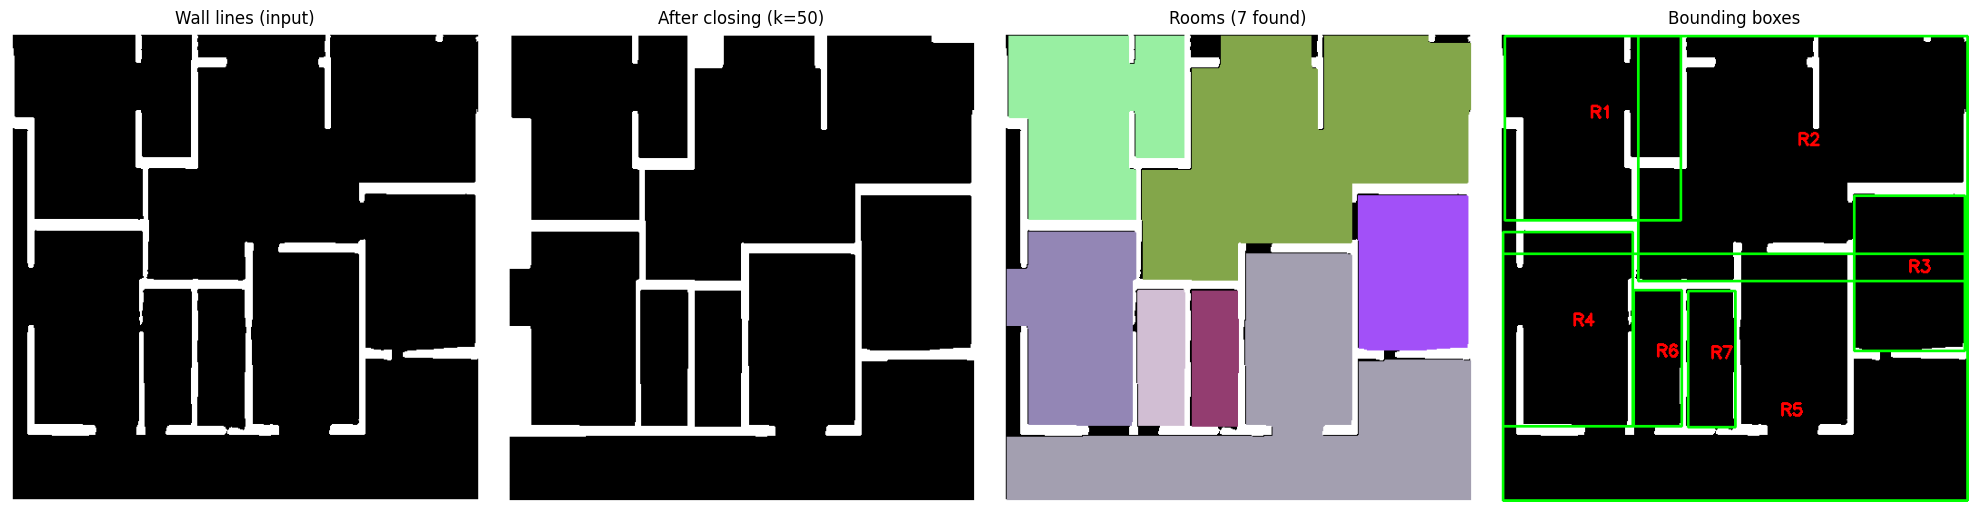

Graph:
Nodes:
  1: [[6, 4], [28, 206], [146, 206], [138, 88], [147, 138], [199, 138], [199, 4], [146, 4], [144, 35], [138, 4]]
  2: [[154, 272], [383, 232], [385, 166], [511, 166], [515, 12], [354, 4], [348, 108], [339, 4], [240, 4], [208, 150], [153, 152]]
  3: [[391, 180], [392, 348], [511, 347], [512, 181]]
  4: [[28, 220], [27, 259], [4, 261], [4, 323], [28, 327], [28, 432], [141, 433], [146, 221]]
  5: [[515, 362], [392, 363], [353, 445], [384, 246], [268, 244], [297, 444], [4, 446], [4, 515], [515, 515]]
  6: [[149, 284], [149, 433], [199, 433], [199, 284]]
  7: [[208, 285], [208, 434], [258, 434], [258, 285]]
Edges:
  1 <-> 2
  1 <-> 3
  1 <-> 4
  1 <-> 5
  1 <-> 6
  1 <-> 7
  2 <-> 3
  2 <-> 4
  2 <-> 5
  2 <-> 6
  2 <-> 7
  3 <-> 4
  3 <-> 5
  3 <-> 6
  3 <-> 7
  4 <-> 5
  4 <-> 6
  4 <-> 7
  5 <-> 6
  5 <-> 7
  6 <-> 7


In [30]:
# make the co-ords as nodes and create a graph with edges as the walls. Then we can apply graph algorithms to find rooms, connectivity, etc.
def build_graph_from_mask(img_path, pred_wall):
    rooms = find_room_boundaries(img_path,pred_wall)
    # create the graph
    graph = {
        "nodes": {},
        "edges": []
    }
    # add nodes
    for room in rooms:
        nid = room['id']
        graph["nodes"][nid] = room['polygon']

    # edges
    for i in range(len(rooms)):
        for j in range(i + 1, len(rooms)):
            room_a = rooms[i]
            room_b = rooms[j]

            # Check if they share a wall (i.e., their contours are close)
            contour_a = room_a['contour']
            contour_b = room_b['contour']

            if contour_a is not None and contour_b is not None:
                dist = cv2.pointPolygonTest(contour_b, tuple(room_a['centroid']), True)

                if dist < 10:  # threshold for "closeness"
                    graph["edges"].append((room_a['id'], room_b['id']))

            # if contour_a is not None and contour_b is not None:

            #     mask_a = np.zeros(pred_wall.shape, dtype=np.uint8)
            #     mask_b = np.zeros(pred_wall.shape, dtype=np.uint8)

            #     cv2.drawContours(mask_a, [contour_a], -1, 255, thickness=5)
            #     cv2.drawContours(mask_b, [contour_b], -1, 255, thickness=5)

            #     overlap = cv2.bitwise_and(mask_a, mask_b)

            #     if np.any(overlap > 0):
            #         graph["edges"].append((room_a['id'], room_b['id']))

    # print the graph
    print("Graph:")
    print("Nodes:")
    for nid, coord in graph["nodes"].items():
        print(f"  {nid}: {coord}")
    print("Edges:")
    for edge in graph["edges"]:
        print(f"  {edge[0]} <-> {edge[1]}")

build_graph_from_mask(img_path, pred_wall)

/tmp/ipykernel_27726/2713698145.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)


Total components found (excl. background): 7
  [KEEP] comp 1: area=  32644, bbox=(6,4,194,203)
  [KEEP] comp 2: area=  67829, bbox=(153,4,363,270)
  [KEEP] comp 3: area=  20620, bbox=(391,180,122,171)
  [KEEP] comp 4: area=  26284, bbox=(4,220,143,214)
  [KEEP] comp 5: area=  69438, bbox=(4,244,512,272)
  [KEEP] comp 6: area=   7837, bbox=(148,284,53,150)
  [KEEP] comp 7: area=   7710, bbox=(208,285,52,150)
Detected 7 rooms
  Room  1: bbox=(6, 4, 194, 203), centroid=(100, 94), area=32644
  Room  2: bbox=(153, 4, 363, 270), centroid=(329, 124), area=67829
  Room  3: bbox=(391, 180, 122, 171), centroid=(451, 264), area=20620
  Room  4: bbox=(4, 220, 143, 214), centroid=(81, 323), area=26284
  Room  5: bbox=(4, 244, 512, 272), centroid=(310, 422), area=69438
  Room  6: bbox=(148, 284, 53, 150), centroid=(173, 357), area=7837
  Room  7: bbox=(208, 285, 52, 150), centroid=(233, 359), area=7710


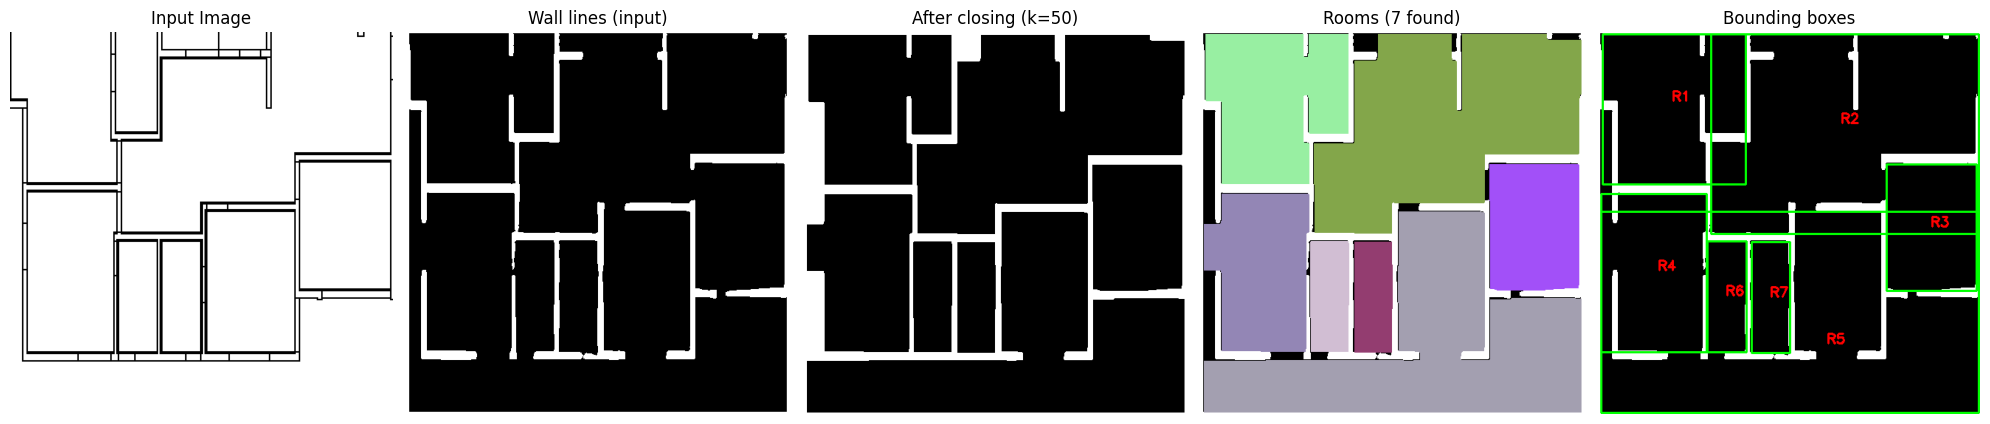

Graph:
Nodes:
  1: [[6, 4], [28, 206], [146, 206], [138, 88], [147, 138], [199, 138], [199, 4], [146, 4], [144, 35], [138, 4]]
  2: [[154, 272], [383, 232], [385, 166], [511, 166], [515, 12], [354, 4], [348, 108], [339, 4], [240, 4], [208, 150], [153, 152]]
  3: [[391, 180], [392, 348], [511, 347], [512, 181]]
  4: [[28, 220], [27, 259], [4, 261], [4, 323], [28, 327], [28, 432], [141, 433], [146, 221]]
  5: [[515, 362], [392, 363], [353, 445], [384, 246], [268, 244], [297, 444], [4, 446], [4, 515], [515, 515]]
  6: [[149, 284], [149, 433], [199, 433], [199, 284]]
  7: [[208, 285], [208, 434], [258, 434], [258, 285]]
Edges:
  1 <-> 2
  1 <-> 4
  2 <-> 3
  2 <-> 4
  2 <-> 5
  2 <-> 6
  3 <-> 5
  4 <-> 5
  4 <-> 6
  6 <-> 7


In [ ]:
import torch
import cv2
import numpy as np
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHTS_PATH = "/opt/dlami/nvme/mitunet_weights/mitunet.pth"

aux_segformer = smp.Segformer(encoder_name="mit_b4", encoder_weights=None)
model = smp.Unet(
    encoder_name="mit_b4",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"
)
# Transplant the encoder
model.encoder = aux_segformer.encoder

# 3. Load trained weights
state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


def predict(img_path, mask_path=None, show=True):

    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    augmented = transform(image=image_rgb)
    input_tensor = augmented['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        mask = (probs > 0.5).float()

    result_mask = mask.squeeze().cpu().numpy()

    # ---------------------------------
    # Load GT mask if provided
    # ---------------------------------
    gt_mask = None

    if mask_path is not None:
        gt_mask = cv2.imread(mask_path, 0)

        # wall only
        gt_mask = (gt_mask == 1).astype(np.uint8)

    # ---------------------------------
    # Plot
    # ---------------------------------
    if show:

        cols = 3 if gt_mask is not None else 2

        plt.figure(figsize=(18, 6))

        # Original image
        plt.subplot(1, cols, 1)
        plt.title("Original Image")
        plt.imshow(image_rgb)
        plt.axis('off')

        # Prediction
        plt.subplot(1, cols, 2)
        plt.title("Predicted Mask")
        plt.imshow(result_mask, cmap='gray')
        plt.axis('off')

        # GT mask
        if gt_mask is not None:
            plt.subplot(1, cols, 3)
            plt.title("GT Wall Mask")
            plt.imshow(gt_mask, cmap='gray')
            plt.axis('off')

        plt.show()

    return result_mask

def find_room_boundaries(img_path, pred_wall):
    # Make a clean binary wall image from your straight_img
    wall_img = (pred_wall > 0).astype(np.uint8) * 255

    # Seal the image border so "outside" can't escape through missing perimeter walls
    border = 3
    wall_img = cv2.copyMakeBorder(wall_img, border, border, border, border,
                                cv2.BORDER_CONSTANT, value=255)

    # Close gaps (doors / windows) so rooms become enclosed
    kernel_size = 50
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    closed = cv2.morphologyEx(wall_img, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Invert -> rooms become white blobs, walls become black barriers
    inverted = cv2.bitwise_not(closed)

    # Find connected components (each blob = one room candidate)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        inverted, connectivity=4
    )

    # Filter out the "outside" region and noise
    H, W = inverted.shape
    total_area = H * W
    min_room_area = 500                 
    max_room_area = total_area * 0.5    

    print(f"Total components found (excl. background): {num_labels - 1}")
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        keep = "KEEP" if min_room_area <= area <= max_room_area else "skip"
        print(f"  [{keep}] comp {i}: area={area:>7}, bbox=({x},{y},{w},{h})")

    rooms = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]

        if area < min_room_area or area > max_room_area:
            continue

        # Get the room's outline as a polygon
        mask = (labels == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour = contours[0] if contours else None

        epsilon = 0.02 * cv2.arcLength(contour, True)
        contour = cv2.approxPolyDP(contour, epsilon, True)

        rooms.append({
            'id':       len(rooms) + 1,
            'label':    i,
            'bbox':     (int(x), int(y), int(w), int(h)),   # x, y, width, height
            'polygon': contour.squeeze().tolist() if contour is not None else None,
            'centroid': (int(cx), int(cy)),
            'area':     int(area),
            'contour':  contour,
        })

    print(f"Detected {len(rooms)} rooms")
    for r in rooms:
        print(f"  Room {r['id']:>2}: bbox={r['bbox']}, centroid={r['centroid']}, area={r['area']}")

    # Colored room fills
    np.random.seed(42)
    room_vis = cv2.cvtColor(wall_img, cv2.COLOR_GRAY2BGR)
    for r in rooms:
        color = np.random.randint(60, 255, size=3).tolist()
        room_vis[labels == r['label']] = color

    # Bounding boxes + IDs on top of the wall image
    bbox_vis = cv2.cvtColor(wall_img, cv2.COLOR_GRAY2BGR)
    for r in rooms:
        x, y, w, h = r['bbox']
        cv2.rectangle(bbox_vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(bbox_vis, f"R{r['id']}", r['centroid'],
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # Plot all stages
    plt.figure(figsize=(20, 5))
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, 1)
    plt.title("Input Image")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.title("Wall lines (input)")
    plt.imshow(wall_img, cmap='gray'); plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.title(f"After closing (k={kernel_size})")
    plt.imshow(closed, cmap='gray'); plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.title(f"Rooms ({len(rooms)} found)")
    plt.imshow(cv2.cvtColor(room_vis, cv2.COLOR_BGR2RGB)); plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.title("Bounding boxes")
    plt.imshow(cv2.cvtColor(bbox_vis, cv2.COLOR_BGR2RGB)); plt.axis('off')

    plt.tight_layout()
    plt.show()

    return rooms

# make the co-ords as nodes and create a graph with edges as the walls. Then we can apply graph algorithms to find rooms, connectivity, etc.
def build_graph_from_mask(rooms):
    # create the graph
    graph = {
        "nodes": {},
        "edges": []
    }
    # add nodes
    for room in rooms:
        nid = room['id']
        graph["nodes"][nid] = room['polygon']

    # edges
    for i in range(len(rooms)):
        for j in range(i + 1, len(rooms)):
            room_a = rooms[i]
            room_b = rooms[j]

            # Check if they share a wall (i.e., their contours are close)
            contour_a = room_a['contour']
            contour_b = room_b['contour']

            if contour_a is not None and contour_b is not None:

                pts_a = contour_a.reshape(-1, 2)
                pts_b = contour_b.reshape(-1, 2)

                close_pts = 0
                dist_thresh = 20
                min_shared_points = 1

                for pt in pts_a:
                    # signed distance to contour_b
                    dist = abs(cv2.pointPolygonTest(
                        contour_b,
                        (float(pt[0]), float(pt[1])),
                        True
                    ))

                    if dist <= dist_thresh:
                        close_pts += 1

                    if close_pts >= min_shared_points:
                        graph["edges"].append((room_a['id'], room_b['id']))
                        break

    # print the graph
    print("Graph:")
    print("Nodes:")
    for nid, coord in graph["nodes"].items():
        print(f"  {nid}: {coord}")
    print("Edges:")
    for edge in graph["edges"]:
        print(f"  {edge[0]} <-> {edge[1]}")

    return graph

def build_graph(img_path):
    pred_wall = predict(img_path, show=False)
    rooms = find_room_boundaries(img_path, pred_wall)
    return build_graph_from_mask(rooms)

if __name__ == "__main__":
    dataset_path = "/opt/dlami/nvme/mitunet_dataset_1/images"

    idx = np.random.randint(0, 100)  # Randomly select an index for testing
    img_path = f"{dataset_path}/{idx:05d}.png"
    build_graph(img_path)

In [ ]:
"""
1. First we've to find the doors or windows which is breaking the closed loop
    1.1: For the identification of the doors or windows, compare two lines slopes ( the nodes ( end of the edges ))
    1.2: if both are same then find is there any other line is connecting these two lines if not then it's a door or window
2. After identifying the doors/windows, we can remove those edges from the graph and check for closed loops 
    2.1: find all the corners of the closed loop and return the coordinates of those corners
"""

"\n1. First we've to find the doors or windows which is breaking the closed loop\n    1.1: For the identification of the doors or windows, compare two lines slopes ( the nodes ( end of the edges ))\n    1.2: if both are same then find is there any other line is connecting these two lines if not then it's a door or window\n2. After identifying the doors/windows, we can remove those edges from the graph and check for closed loops \n    2.1: find all the corners of the closed loop and return the coordinates of those corners\n"

: 

Room 0: 56 corners, area=58904
   (366, 144)
   (368, 144)
   (409, 144)
   (410, 145)
   (466, 145)
   (467, 144)
   (489, 144)
   (490, 145)
   (505, 145)
   (509, 149)
   (509, 485)
   (508, 486)
   (508, 487)
   (509, 488)
   (509, 496)
   (504, 501)
   (462, 501)
   (461, 502)
   (460, 502)
   (459, 503)
   (458, 503)
   (457, 504)
   (456, 504)
   (397, 501)
   (396, 501)
   (395, 502)
   (392, 502)
   (391, 501)
   (367, 501)
   (366, 502)
   (341, 502)
   (340, 501)
   (304, 501)
   (340, 499)
   (341, 498)
   (341, 485)
   (340, 484)
   (340, 454)
   (341, 453)
   (341, 299)
   (340, 298)
   (340, 280)
   (339, 279)
   (340, 278)
   (340, 195)
   (341, 194)
   (342, 193)
   (343, 192)
   (351, 192)
   (352, 193)
   (365, 193)
   (368, 190)
   (368, 179)
   (367, 178)
   (367, 149)
   (368, 148)
Room 1: 26 corners, area=6727
   (333, 47)
   (338, 47)
   (340, 49)
   (340, 50)
   (341, 51)
   (341, 144)
   (340, 145)
   (313, 145)
   (312, 146)
   (304, 146)
   (283, 146)
   (28

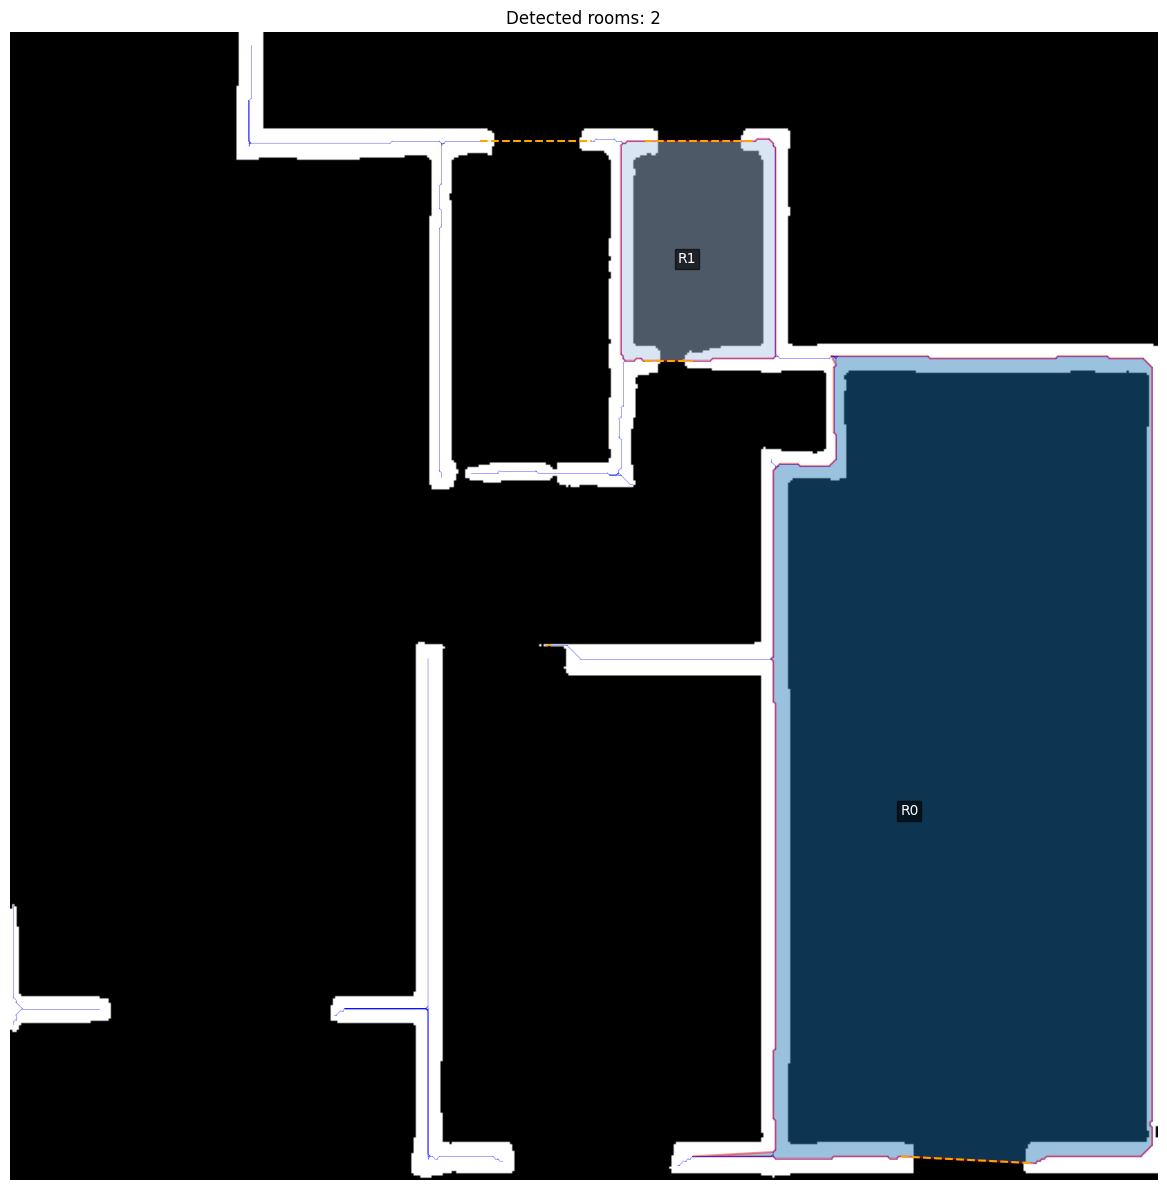

: 

In [ ]:
import math
from collections import defaultdict


def find_rooms(graph, max_gap_distance=100, max_angle_deg=30):
    """
    Find rooms (closed polygons) from a wall-skeleton graph.

    Args:
        graph: {"nodes": {id: (x, y)}, "edges": [(a, b, path)]}
        max_gap_distance: max pixel distance to bridge across a door/window
        max_angle_deg: max allowed deviation from colinearity (degrees)

    Returns:
        rooms:   list of dicts {"node_ids", "coords", "area"}
        bridges: list of (node_a, node_b) edges added to close gaps
    """
    nodes = graph["nodes"]
    edges = graph["edges"]

    # adjacency from the existing graph (we ignore the pixel paths here —
    # only the topology matters for face enumeration)
    adj = defaultdict(set)
    for a, b, _ in edges:
        if a == b:
            continue
        adj[a].add(b)
        adj[b].add(a)

    # -------------------------------------------------
    # STEP 1: endpoints (degree-1 nodes)
    # -------------------------------------------------
    endpoints = [nid for nid in nodes if len(adj[nid]) == 1]

    # -------------------------------------------------
    # STEP 2: pair endpoints across door/window gaps
    # -------------------------------------------------
    def outward_dir(nid):
        """Unit vector at `nid` pointing away from its only neighbor
        (i.e. the direction the wall would continue if not broken)."""
        nbr = next(iter(adj[nid]))
        x1, y1 = nodes[nid]
        x2, y2 = nodes[nbr]
        dx, dy = x1 - x2, y1 - y2
        n = math.hypot(dx, dy)
        return (dx / n, dy / n) if n > 0 else (0.0, 0.0)

    def angle_deg(v1, v2):
        d = max(-1.0, min(1.0, v1[0] * v2[0] + v1[1] * v2[1]))
        return math.degrees(math.acos(d))

    # score every candidate pair, then do greedy matching by best score
    candidates = []
    for i, ep1 in enumerate(endpoints):
        x1, y1 = nodes[ep1]
        d1 = outward_dir(ep1)
        for ep2 in endpoints[i + 1:]:
            x2, y2 = nodes[ep2]
            dist = math.hypot(x2 - x1, y2 - y1)
            if dist == 0 or dist > max_gap_distance:
                continue

            d2 = outward_dir(ep2)
            gap_dir = ((x2 - x1) / dist, (y2 - y1) / dist)

            # both walls must point toward each other along the gap
            a1 = angle_deg(d1, gap_dir)
            a2 = angle_deg(d2, (-gap_dir[0], -gap_dir[1]))
            if a1 > max_angle_deg or a2 > max_angle_deg:
                continue

            candidates.append((dist + 2 * (a1 + a2), ep1, ep2))

    candidates.sort()
    bridges = []
    paired = set()
    for _, ep1, ep2 in candidates:
        if ep1 in paired or ep2 in paired:
            continue
        bridges.append((ep1, ep2))
        paired.add(ep1)
        paired.add(ep2)

    for a, b in bridges:
        adj[a].add(b)
        adj[b].add(a)

    # -------------------------------------------------
    # STEP 3: sort each node's neighbors by angle
    # -------------------------------------------------
    sorted_nbrs = {}
    for nid, nbrs in adj.items():
        x, y = nodes[nid]
        sorted_nbrs[nid] = sorted(
            nbrs,
            key=lambda n: math.atan2(nodes[n][1] - y, nodes[n][0] - x),
        )

    # -------------------------------------------------
    # STEP 4: walk half-edges to enumerate faces
    # -------------------------------------------------
    # For directed edge (u -> v), the next edge in the same face is the
    # neighbor of v immediately CW (= previous in CCW-sorted list) from u.
    visited = set()
    faces = []

    for start_u in list(adj.keys()):
        for start_v in sorted_nbrs[start_u]:
            if (start_u, start_v) in visited:
                continue

            face = []
            u, v = start_u, start_v
            guard = 0
            limit = 4 * sum(len(n) for n in sorted_nbrs.values()) + 10

            while (u, v) not in visited:
                visited.add((u, v))
                face.append(u)

                nbrs = sorted_nbrs[v]
                idx = nbrs.index(u)
                u, v = v, nbrs[(idx - 1) % len(nbrs)]

                guard += 1
                if guard > limit:  # paranoia
                    break

            if len(face) >= 3:
                faces.append(face)

    # -------------------------------------------------
    # STEP 5: drop the outer face (largest |area|)
    # -------------------------------------------------
    def signed_area(face):
        a = 0.0
        n = len(face)
        for i in range(n):
            x1, y1 = nodes[face[i]]
            x2, y2 = nodes[face[(i + 1) % n]]
            a += x1 * y2 - x2 * y1
        return a / 2

    rooms = []
    for face in faces:
        area = abs(signed_area(face))
        rooms.append({
            "node_ids": face,
            "coords": [nodes[n] for n in face],
            "area": area,
        })

    rooms.sort(key=lambda r: r["area"], reverse=True)
    rooms = rooms[1:]   # the biggest face is the outside of the building

    # optionally filter tiny artifact faces
    rooms = [r for r in rooms if r["area"] > 50]

    return rooms, bridges


# -----------------------------------------------------
# Visualization helper
# -----------------------------------------------------
def visualize_rooms(mask, graph, rooms, bridges=None):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(mask, cmap="gray")

    # draw original graph edges faintly
    for a, b, path in graph["edges"]:
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, color="blue", linewidth=0.6, alpha=0.4)

    # bridges (the closed gaps)
    if bridges:
        for a, b in bridges:
            (x1, y1), (x2, y2) = graph["nodes"][a], graph["nodes"][b]
            ax.plot([x1, x2], [y1, y2], color="orange",
                    linewidth=1.5, linestyle="--")

    # fill rooms
    cmap = plt.cm.tab20
    for i, room in enumerate(rooms):
        poly = patches.Polygon(
            room["coords"],
            closed=True,
            facecolor=cmap(i % 20),
            edgecolor="red",
            alpha=0.45,
            linewidth=1.5,
        )
        ax.add_patch(poly)

        cx = np.mean([c[0] for c in room["coords"]])
        cy = np.mean([c[1] for c in room["coords"]])
        ax.text(cx, cy, f"R{i}", color="white",
                fontsize=10, ha="center", va="center",
                bbox=dict(facecolor="black", alpha=0.6, pad=2))

    ax.set_title(f"Detected rooms: {len(rooms)}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


graph = build_graph_from_mask(pred_wall)
rooms, bridges = find_rooms(graph,
                            max_gap_distance=60,
                            max_angle_deg=25)

for i, r in enumerate(rooms):
    print(f"Room {i}: {len(r['coords'])} corners, area={r['area']:.0f}")
    for (x, y) in r["coords"]:
        print(f"   ({x}, {y})")

visualize_rooms(pred_wall, graph, rooms, bridges)

: 